# Basic Fault Network Modeling with Fermi

Fermi is a tool to create fault sources for PSHA that are capable of 
subfault to multifault ruptures, treating the faults as a network.

This is an entry-level tutorial. 

# Overview of the Fault Network Modeling process

The modeling process looks like this:

1. Creation of subfaults

    In this step, the fault traces are expanded down-dip to 3D surfaces, and then broken into smaller, atomic units called 'subfaults' that are capable of independent ruptures. The individual subfault ruptures are the smallest on-fault ruptures in the fault source. For regional PSHA models, 10x10 km subfaults are a fine subfault size, which is about a M 6.0 rupture. This can be smaller or larger if desired, for example smaller for site-specific studies, or larger for continental-scale models; the tradeoffs here are the number of ruptures produced and the computational expense in the rupture creation and rate inversion.

1. Creation of single-fault ruptures

   Single-fault ruptures are composed of one or more subfaults. Ruptures with more than one subfault are rectangular groups of contiguous subfaults. These fall within rupture aspect ratio bounds, which are different for ruptures that don't fully saturate the down-dip width of the fault and those that do: ruptures that do are allowed to grow much longer than those that do not, consistent with observations from nature. Note that these aspect ratio bounds are configurable.

1. Creation of multifault ruptures

    Multifault ruptures are created by joining single-fault ruptures that are separated by a 'jump' distance less than some specified value (typically 5-10 km). This is done through graph theoretical methods: a N x N distance matrix is created (where N is the number of ruptures) and then this matrix is pared for distances greater than the jump distance, creating an adjacency matrix. Then, all of the unique sets of adjacent ruptures is found through a depth-first search algorithm operating on the adjacency matrix.

    This typically produces an enormous number of ruptures, so additional filtering should be done on the adjacency matrix before the multifault ruptures are created. The most substantial is limiting multifault ruptures to be combinations of full-fault single-fault ruptures (rather than all subfault ruptures), which for reasons of computational expense will need to be done when more than a few faults are involved, unless one wants to use an HPC system or the subfaults themselves are >20x20 km. This is in line with theory and observations suggesting that earthquake ruptures are much more likely to stop at geometric complexities in faults (including gaps and stepovers) than in the middle of fault segments. Similarly, the geometrical compatibilities between faults themselves can be quantified and used as a filter on the adjacency matrix.

1. (Optional) Plausibility filtering of multifault ruptures

    Research of rupture propagation through geometrical complexities and related topics indicates that not all potential multifault ruptures are equally plausible. Therefore, we can increase the model's fidelity to nature and reduce its computational load by filtering the ruptures by their plausbility. The plausibility of a rupture is quantified by assessing the jump distance, the angular distance between the traces of adjacent faults, and the angular distance between the azimuth of slip between adjacent faults; each of these yields a plausibility value between 0 and 1 for each connection between faults (or ruptures), which are multiplied 

1. Rupture rate inversion

   1. Choosing constraints

   1. making system of equations

   1. Solving

1. Writing fault sources

In [1]:
# Start the logging with level INFO to provide
# good information about the progress and results

import logging
logging.basicConfig(
    format='%(asctime)s - %(message)s',
    datefmt='%d-%b-%y %H:%M:%S',
    level=logging.INFO,
)

Fermi is the `openquake.fnm` module. The basic entry point is the `openquake.fnm.all_together_now` submodule,
which provides the functions `build_fault_network` and `build_system_of_equations`. 

However, we are also going to import a number of other functions to allow us
to use more constraints in solving for the rupture rates, such as magnitude-frequency constraints for all of the faults involved as well as for the region.

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from openquake.hazardlib.mfd import TruncatedGRMFD

from openquake.fnm.exporter import (
    make_multifault_source,
    write_multifault_source,
)
from openquake.fnm.all_together_now import (
    build_fault_network,
    build_system_of_equations,
)
from openquake.fnm.inversion.utils import (
    rup_df_to_rupture_dicts,
    get_fault_moment_rate,
    make_fault_mfd,
)
from openquake.fnm.inversion.plots import (
    plot_soln_slip_rates,
    plot_soln_mfd,
    plot_mfd,
)
from openquake.fnm.inversion.soe_builder import (
    make_fault_rel_mfd_equation_components,
)

from openquake.fnm.inversion.solver import solve_nnls_pg

Fault network modeling is complex; there are a number of parameters that control many of the aspects of the process. 

In [3]:
settings = {
    # fraction of slip rate released in mainshocks
    "seismic_fraction": 1.0, 
    # Size of subfault length/width in km
    "subsection_size": 10.0, 
    "max_jump_distance": 10.0, # maximum 3d distance between faults that can co-rupture
    "parallel_subfault_build": True, #set to False if you run in IPython interactively
    'full_fault_only_mf_ruptures': True, # Set to False for site-specific analysis with just a few faults
    "filter_by_plausibility": True, #set to True if you want to remove some geometrically implausible ruptures
    "fault_mfd_b_value": 1.0, # change as you like
    "export_fault_mfds": True, # create MFD objects for faults during processing
}

In [4]:
fault_geojson = "../../../../openquake/fnm/tests/data/atf_qilian.geojson"

Warning 3: Cannot find header.dxf (GDAL_DATA is not defined)
/Users/itchy/src/miniforge3/envs/oq2/lib/python3.12/site-packages/pyogrio/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


<Axes: >

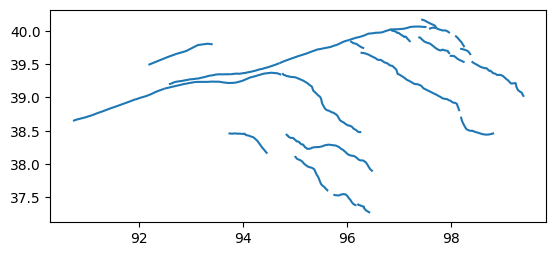

In [5]:
gpd.read_file(fault_geojson).plot()

In [6]:
fault_network = build_fault_network(
        fault_geojson=fault_geojson,
        settings=settings,
        )

18-Mar-26 16:43:32 - Building faults from geojson
18-Mar-26 16:43:32 - 	27 faults built from geojson
18-Mar-26 16:43:32 - 	done in 0.1 s
18-Mar-26 16:43:32 - Making subfaults in parallel
18-Mar-26 16:43:39 - 	done in 7.1 s
18-Mar-26 16:43:39 - 	828 subfaults from 27 faults
18-Mar-26 16:43:39 - Making single fault rup df and distance matrix
18-Mar-26 16:43:39 -   making single-fault ruptures
18-Mar-26 16:43:39 -   calculating fault distances
18-Mar-26 16:43:39 -   making dist_adj_matrix (7046, 7046)
18-Mar-26 16:43:39 -   filtering and calculating pairwise rupture distances
18-Mar-26 16:43:40 - 	done in 0.6 s
18-Mar-26 16:43:40 - 	7,046 single-fault ruptures
18-Mar-26 16:43:40 - 	64 close ruptures out of 4,096 connections (1.6%)
18-Mar-26 16:43:40 -   Filtering by rupture overlap
18-Mar-26 16:43:40 -    Getting proximal rup angles
18-Mar-26 16:43:40 -    Calculating overlap
18-Mar-26 16:43:40 - 	done in 0.4 s
18-Mar-26 16:43:40 - 	50 connections remaining
18-Mar-26 16:43:40 - Building s

In [7]:
rup_key = 'rupture_df'
rup_set = fault_network[rup_key]
rups = rup_df_to_rupture_dicts(rup_set)

In [8]:
# MFD constraints (b-value only, no a-value) for faults
fault_rel_mfds = make_fault_rel_mfd_equation_components(
    rups,
    fault_network,
    b_value=settings['fault_mfd_b_value'],
    fault_key='faults',
    rup_key=rup_key,
    )

In [9]:
# absolute MFD for whole model
fault_moment = sum(get_fault_moment_rate(fault) 
                   for i, fault in fault_network['subfault_df'].iterrows())
model_abs_mfd = TruncatedGRMFD.from_moment(
    min_mag=rup_set.mag.min(),
    max_mag=rup_set.mag.max(),
    bin_width=0.1,
    b_val=1.0, # as you'd like
    moment_rate=fault_moment,
)



In [10]:
lhs, rhs, err = build_system_of_equations(
    rup_set,
    fault_network["subfault_df"],
    fault_rel_mfds=fault_rel_mfds,
    mfd_rel_weight=1e2,
    mfd_rel_mode='shape',
    #mfd_rel_eqns=True, # if you want a regional (relative, no a-value) MFD
    mfd_rel_b_val=1.0, # adjust as you'd like,
    mfd=model_abs_mfd, # set to None if you don't want to use
)

18-Mar-26 16:44:25 - Making slip rate eqns
18-Mar-26 16:44:26 - Making regional MFD relative eqns
18-Mar-26 16:44:26 - Making MFD absolute eqns
18-Mar-26 16:44:26 - stacking results


In [11]:
logging.info("Solving")
rup_rates, misfit_history = solve_nnls_pg(
    lhs,
    rhs,
    weights=err,
    max_iters=int(2e5),
    accept_grad=-1, # continue to completion of iterations
    accept_norm=-1, # continue to completion of iterations
    stall_val=1e-6, # continue until solutions is pretty stable
)
rup_rates = pd.Series(rup_rates, index=rup_set.index)
logging.info("Done solving")

18-Mar-26 16:44:26 - Solving
18-Mar-26 16:48:32 - Done solving


In [12]:
rup_set["occurrence_rate"] = rup_rates

Text(0.5, 1.0, 'Observed and modeled slip rates')

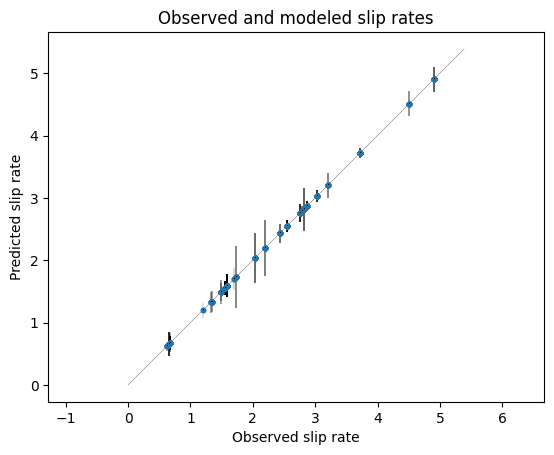

In [13]:
plt.figure()
plot_soln_slip_rates(
    rup_rates,
    fault_network['subfault_df'].net_slip_rate,
    lhs,
    errs=fault_network["subfault_df"].net_slip_rate_err,
    units="mm/yr",
)
plt.title("Observed and modeled slip rates")

Text(0.5, 1.0, 'Solution MFD')

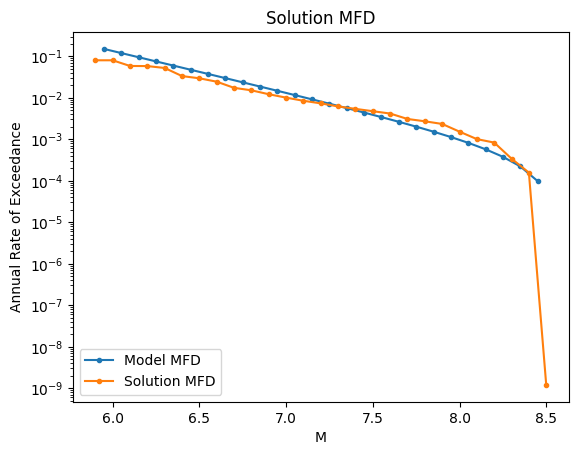

In [14]:
plt.figure()
plot_mfd(model_abs_mfd, label="Model MFD")
plot_soln_mfd(rup_rates.values, rups, label="Solution MFD")
plt.legend(loc="lower left")
plt.title("Solution MFD")

Text(0.5, 1.0, 'Solution misfit history')

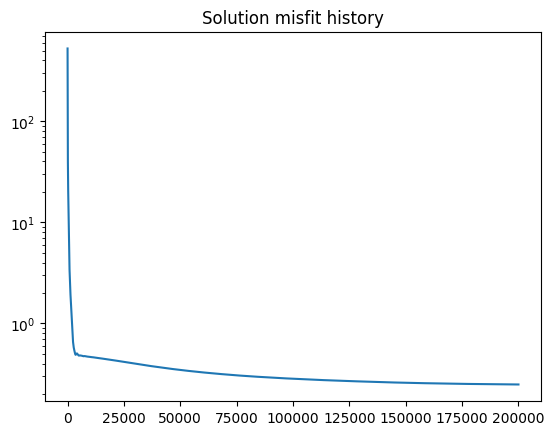

In [15]:
plt.figure()
plt.semilogy(misfit_history)
plt.title("Solution misfit history")